# Market Risk Analysis of Tesla (TSLA)
## Volatility Forecasting, VaR, ES, and Option Risk

---

Haesoo Pyun  
**Language:** Python (Jupyter Notebook)

---

## 1. Introduction

This report evaluates the downside risk of an investment in Tesla (TSLA), a stock characterised by high volatility and non-normal return behaviour. The analysis focuses on 1-day 99% Value at Risk (VaR) and Expected Shortfall (ES), key measures used in market-risk regulation and internal capital modelling (Basel Committee, 2013). VaR identifies the loss threshold exceeded on 1 out of every 100 trading days, while ES captures the average loss when this threshold is breached, providing a deeper assessment of tail severity.

The objective is to compare several prominent approaches to measuring short-horizon risk and to examine how their assumptions shape the resulting estimates. The methods include parametric techniques, semi-parametric procedures that incorporate time-varying volatility, and a tail-focused Peaks Over Threshold (POT) model from Extreme Value Theory. A full re-pricing Monte Carlo simulation is also applied to a 1-month at-the-money call option to capture non-linear risk.

## 2. Method

This report quantifies the 1-day 99% Value at Risk (VaR) and Expected Shortfall (ES) for Tesla stock and a call option using distinct methodologies for both unconditional and conditional volatility. Using multiple approaches mitigates model risk and reveals sensitivity to assumptions (Jorion, 2007). All VaR and ES are computed using daily simple returns, and losses are defined as $L_t = -r_t$ so that large negative returns correspond to large positive losses.

### 2.1 Volatility Estimation

Volatility enters every model as the scale parameter of return risk. Two measures are employed.

Unconditional Volatility ($\sigma_{uncond}$) is the sample standard deviation of daily simple returns over the full historical period, assuming a constant variance process:

$$\sigma_{uncond} = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (r_i - \bar{r})^2}$$

Conditional Volatility ($\sigma_{cond}$) is estimated using the EWMA(0.94) model, which updates volatility according to recent return shocks and captures volatility clustering:

$$\sigma_t^2 = \lambda \sigma_{t-1}^2 + (1 - \lambda) r_{t-1}^2$$

where $\lambda = 0.94$, following the RiskMetrics framework (J.P. Morgan, 1996).

### 2.2 Variance-Covariance (VCV) Approach

The VCV approach assumes normally distributed returns with zero mean:

$$VaR_{0.99} = \sigma \cdot \Phi^{-1}(0.99)$$

$$ES_{0.99} = \sigma \cdot \frac{\phi(\Phi^{-1}(0.01))}{0.01}$$

### 2.3 Standardised Historical Simulation

Returns are standardised using EWMA volatility: $z_t = \frac{r_t - \mu}{\sigma_t}$. The first 250 volatility estimates are excluded to avoid distortion from model initialisation. The 1% quantile of the standardised returns is then re-scaled to obtain VaR, and ES is computed as the mean of standardised returns below this quantile.

### 2.4 Monte Carlo Simulation (GBM)

200,000 one-day price paths are simulated under Geometric Brownian Motion:

$$S_{t+1} = S_t \cdot \exp\left[\left(r_f - 0.5\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t} \cdot Z\right]$$

where $Z \sim N(0,1)$ and $\Delta t = 1/252$.

### 2.5 Peaks Over Threshold (POT)

The POT model fits a Generalised Pareto Distribution (GPD) to excess losses above the 95th percentile threshold $u$:

$$VaR_{0.99} = u + \frac{\beta}{\xi}\left[\left(\frac{0.01}{n_u/n}\right)^{-\xi} - 1\right]$$

$$ES_{0.99} = \frac{VaR_{0.99} + (\beta - \xi u)}{1 - \xi}$$

### 2.6 Option VaR and ES (Full Re-pricing)

For the at-the-money call option, risk is measured using full re-pricing via the Black-Scholes model:

$$C = S\Phi(d_1) - Ke^{-rT}\Phi(d_2)$$

where $d_1 = \frac{\ln(S/K) + (r + 0.5\sigma^2)T}{\sigma\sqrt{T}}$ and $d_2 = d_1 - \sigma\sqrt{T}$. Each simulated stock price from GBM is re-valued using Black-Scholes with the implied volatility from the options market.

## 3. Setup and Data

### 3.1 Libraries and Parameters

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 150,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.edgecolor': '0.2',
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'serif',
})

COLOURS = {
    'return': '#6c757d',
    'var': '#dc3545',
    'es': '#0d6efd',
    'hist': '#adb5bd',
    'normal': '#dc3545',
    'mc_hist': '#868e96',
    'gpd_pt': '#0d6efd',
}

# Parameters
ALPHA       = 0.01           # 99% VaR/ES
LAMBDA_EWMA = 0.94           # EWMA decay factor (RiskMetrics)
TRADING_DAYS = 252
SEED        = 50
NSIMS       = 200_000        # Monte Carlo simulations

np.random.seed(SEED)

# Output directory
FIG_DIR = os.path.join('..', 'Python_figures')
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    """Save figure to figures/ directory and display inline."""
    fig.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()

print('Setup complete.')

Setup complete.


### 3.2 Data Acquisition

The analysis uses daily adjusted closing prices for TSLA sourced from Yahoo Finance via the `yfinance` API. The sample covers approximately 5 years of trading data up to the most recent available date.

In [3]:
# Pull TSLA data
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
start_date = (pd.Timestamp.today() - pd.DateOffset(years=5)).strftime('%Y-%m-%d')

tsla = yf.download('TSLA', start=start_date, end=end_date, auto_adjust=True, progress=False)

if isinstance(tsla.columns, pd.MultiIndex):
    tsla.columns = tsla.columns.get_level_values(0)

tsla = tsla[['Close']].dropna().copy()
tsla.columns = ['adj_close']
tsla.index.name = 'date'
tsla = tsla.sort_index()

S_t = tsla['adj_close'].iloc[-1]  # Current spot price
as_of = tsla.index[-1]

print(f'Data period  : {tsla.index[0].strftime("%Y-%m-%d")} to {as_of.strftime("%Y-%m-%d")}')
print(f'Observations : {len(tsla):,}')
print(f'Spot price   : ${S_t:.2f}')

Data period  : 2021-04-16 to 2026-04-15
Observations : 1,255
Spot price   : $391.95


In [4]:
# Compute daily returns
df = tsla.copy()
df['r_simple'] = df['adj_close'].pct_change()
df['r_log']    = np.log(df['adj_close']) - np.log(df['adj_close'].shift(1))
df = df.dropna().copy()

print(f'Return observations: {len(df):,}')

Return observations: 1,254


### 3.3 Descriptive Statistics

Table 1 presents the key descriptive statistics for the daily simple returns of TSLA. The kurtosis is the most critical statistic. A normal distribution has a kurtosis of 3, so values significantly greater than 3 indicate a leptokurtic (fat-tailed) distribution. The presence of fat tails in equity returns is well-documented in empirical finance, with extreme movements occurring far more frequently than the normal model predicts (Danielsson and de Vries, 1997).

In [5]:
# Descriptive statistics 
r = df['r_simple'].values

desc = pd.DataFrame({
    'Statistic': ['n', 'Mean Daily Return', 'Standard Deviation',
                  'Skewness', 'Kurtosis', 'Minimum', 'Maximum'],
    'Value': [
        f'{len(r):,}',
        f'{r.mean():.4%}',
        f'{r.std(ddof=1):.4%}',
        f'{stats.skew(r):.4f}',
        f'{stats.kurtosis(r, fisher=False):.4f}',  # Excess=False → raw kurtosis
        f'{r.min():.4%}',
        f'{r.max():.4%}',
    ]
})

print('Table 1: Descriptive Statistics of Daily Simple Returns')
print('=' * 45)
for _, row in desc.iterrows():
    print(f'  {row["Statistic"]:<25s} {row["Value"]:>15s}')

Table 1: Descriptive Statistics of Daily Simple Returns
  n                                   1,254
  Mean Daily Return                 0.1058%
  Standard Deviation                3.7204%
  Skewness                           0.3001
  Kurtosis                           6.0762
  Minimum                         -15.4262%
  Maximum                          22.6900%


### 3.4 Price and Return Visualisation

Figure 1 illustrates the price evolution, which characterises significant trends and periods of high volatility.

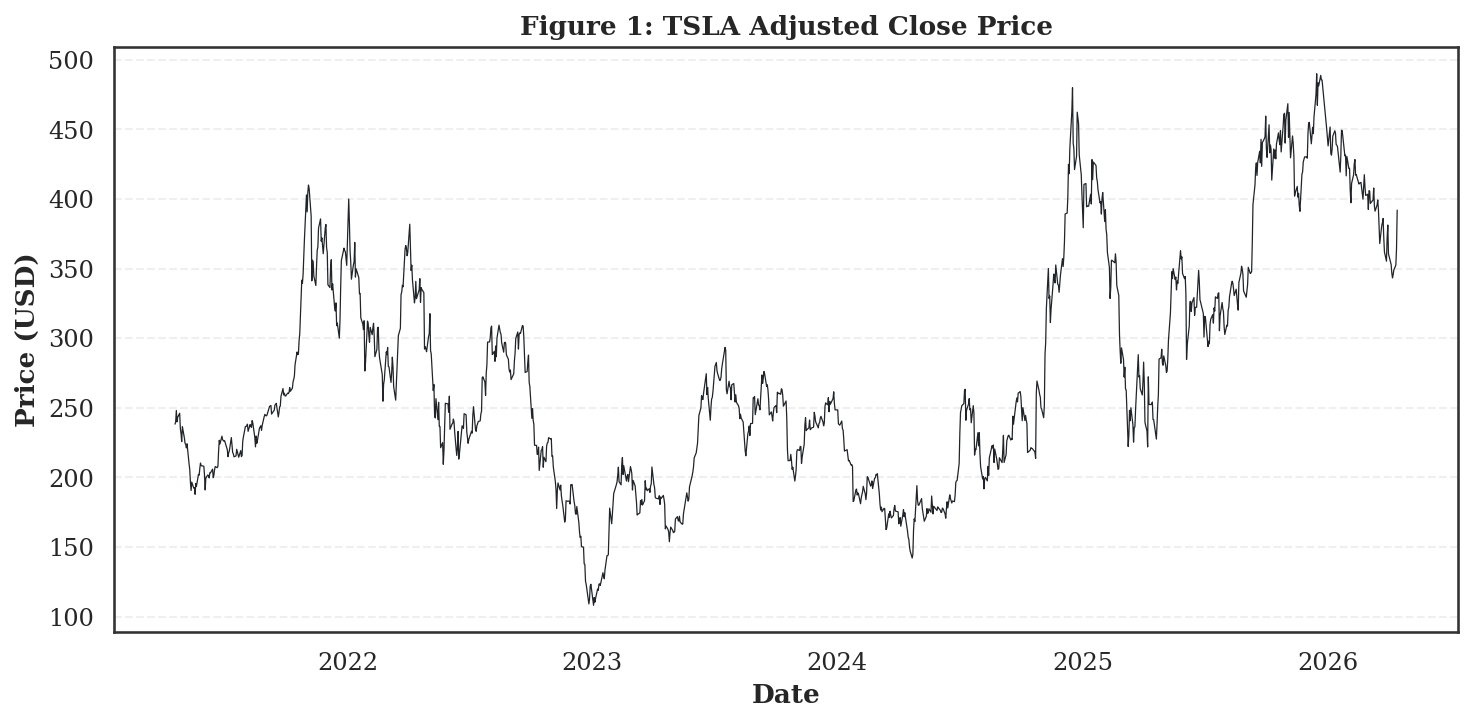

In [6]:
# Figure 1: Price chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['adj_close'], linewidth=0.6, color='#212529')
ax.set_title('Figure 1: TSLA Adjusted Close Price')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='x', alpha=0)
fig.tight_layout()
save_fig(fig, 'fig_price.png')

Figure 2 converts the daily price series into simple returns $(P_t / P_{t-1} - 1)$. Volatility clustering is clearly visible. Alternating periods of high and low volatility motivate the use of time-varying volatility models.

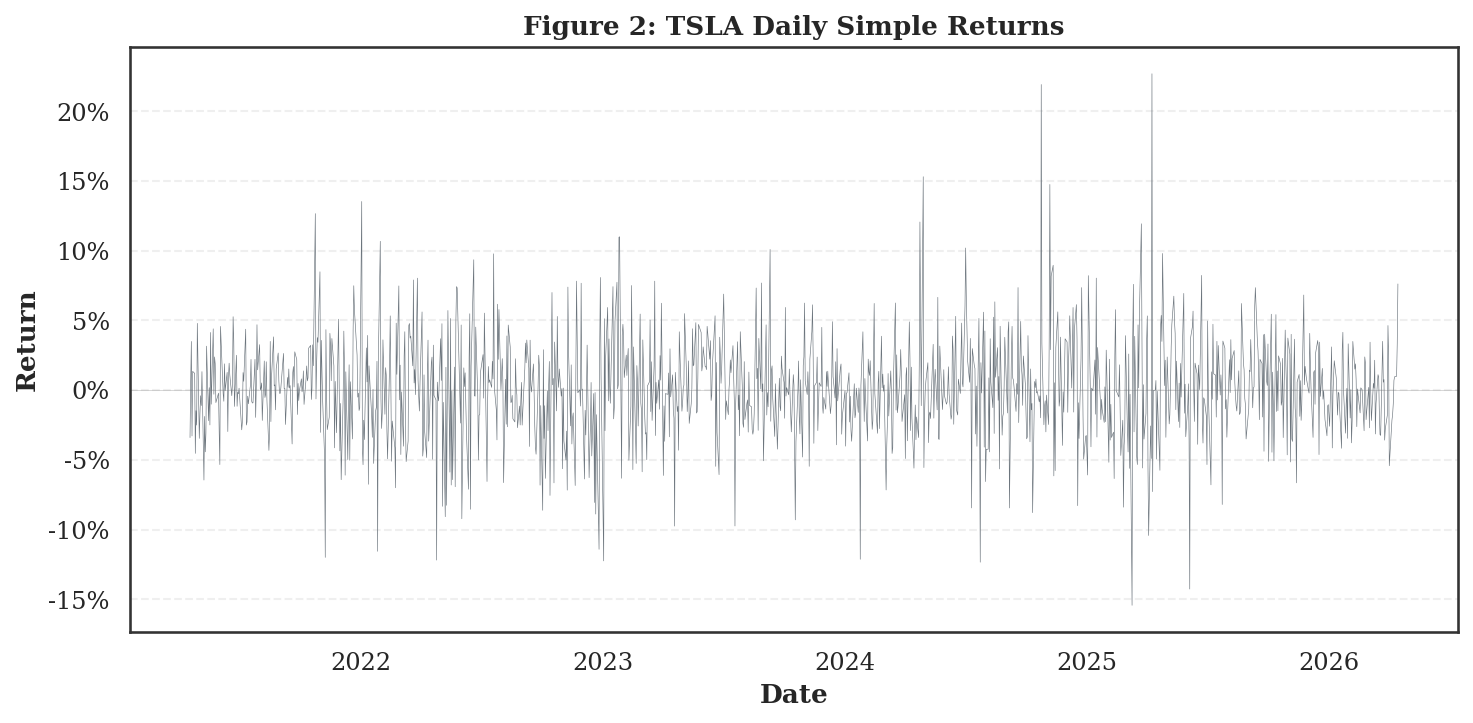

In [7]:
# Figure 2: Returns chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, color='grey', linewidth=0.3, alpha=0.5)
ax.plot(df.index, df['r_simple'], linewidth=0.3, color=COLOURS['return'])
ax.set_title('Figure 2: TSLA Daily Simple Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Return')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='x', alpha=0)
fig.tight_layout()
save_fig(fig, 'fig_return.png')

## 4. Results

### 4.1 Volatility Estimation

We compute unconditional volatility (sample standard deviation) and conditional volatility via the EWMA(0.94) model. The conditional estimate responds to volatility clustering and places greater weight on recent information, making it more appropriate for a 1-day ahead risk forecast.

In [8]:
# EWMA variance recursion
def ewma_variance(returns, lam, v0=None):
    """
    EWMA variance recursion: σ²_t = λ σ²_{t-1} + (1-λ) r²_{t-1}
    Returns array of conditional variances (same length as returns).
    """
    n = len(returns)
    if v0 is None:
        v0 = np.var(returns, ddof=1)
    var_series = np.empty(n)
    var_series[0] = v0
    for i in range(1, n):
        var_series[i] = lam * var_series[i-1] + (1 - lam) * returns[i-1]**2
    return var_series

# Volatility estimates
sigma_uncond = np.std(r, ddof=1)

var_ewma = ewma_variance(r, LAMBDA_EWMA, v0=sigma_uncond**2)
sigma_ewma = np.sqrt(var_ewma)
sigma_cond_forecast = sigma_ewma[-1]  # 1-step ahead forecast

print(f'Unconditional σ (daily)  : {sigma_uncond:.4%}')
print(f'Conditional σ forecast   : {sigma_cond_forecast:.4%}')
print(f'Ratio (cond / uncond)    : {sigma_cond_forecast / sigma_uncond:.3f}')

Unconditional σ (daily)  : 3.7204%
Conditional σ forecast   : 2.4508%
Ratio (cond / uncond)    : 0.659


### 4.2 Variance-Covariance (VCV) VaR and ES

Under the VCV framework, VaR and ES depend solely on the chosen volatility input and the normal distribution assumption.

In [9]:
# Black-Scholes call pricing function
def bs_call(S, K, r_cont, sigma_a, T_years):
    """Black-Scholes European call price."""
    if T_years <= 0:
        return np.maximum(S - K, 0.0)
    d1 = (np.log(S / K) + (r_cont + 0.5 * sigma_a**2) * T_years) / (sigma_a * np.sqrt(T_years))
    d2 = d1 - sigma_a * np.sqrt(T_years)
    return S * stats.norm.cdf(d1) - K * np.exp(-r_cont * T_years) * stats.norm.cdf(d2)

# VCV VaR & ES
z_alpha = stats.norm.ppf(ALPHA)  # z_{0.01} ≈ -2.326

VaR_vcv_uncond = -sigma_uncond * z_alpha
ES_vcv_uncond  =  sigma_uncond * stats.norm.pdf(z_alpha) / ALPHA

VaR_vcv_cond   = -sigma_cond_forecast * z_alpha
ES_vcv_cond    =  sigma_cond_forecast * stats.norm.pdf(z_alpha) / ALPHA

print('VCV Results (99%, 1-day):')
print(f'  Unconditional  VaR = {VaR_vcv_uncond:.4%}   ES = {ES_vcv_uncond:.4%}')
print(f'  Conditional    VaR = {VaR_vcv_cond:.4%}   ES = {ES_vcv_cond:.4%}')

VCV Results (99%, 1-day):
  Unconditional  VaR = 8.6550%   ES = 9.9157%
  Conditional    VaR = 5.7014%   ES = 6.5319%


Figure 3 illustrates how the 99% conditional VaR and ES evolve through time when the EWMA volatility forecast is used. We observe widening during volatile periods and narrowing during stable market conditions.

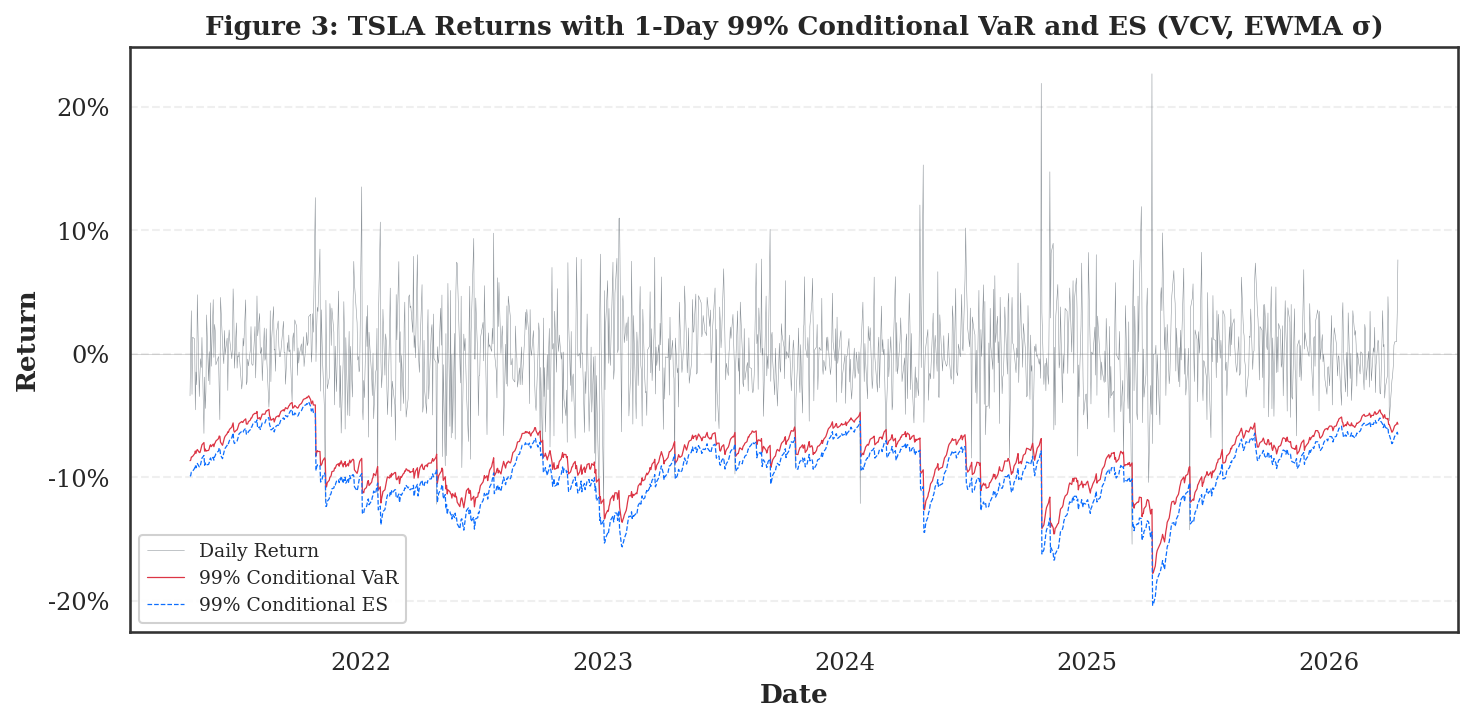

In [10]:
# Figure 3: Conditional VaR/ES bands
VaR_cond_line = z_alpha * sigma_ewma        # negative (loss boundary)
ES_cond_line  = -sigma_ewma * stats.norm.pdf(z_alpha) / ALPHA  # negative

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, color='grey', linewidth=0.3, alpha=0.5)
ax.plot(df.index, df['r_simple'], linewidth=0.25, color=COLOURS['return'],
        label='Daily Return', alpha=0.8)
ax.plot(df.index, VaR_cond_line, linewidth=0.6, color=COLOURS['var'],
        label='99% Conditional VaR')
ax.plot(df.index, ES_cond_line, linewidth=0.6, color=COLOURS['es'],
        linestyle='--', label='99% Conditional ES')

ax.set_title('Figure 3: TSLA Returns with 1-Day 99% Conditional VaR and ES (VCV, EWMA σ)')
ax.set_xlabel('Date')
ax.set_ylabel('Return')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
ax.grid(axis='x', alpha=0)
fig.tight_layout()
save_fig(fig, 'fig_condVaR.png')

### 4.3 Normality Assessment

The fat-tailed nature of the returns is confirmed by the Q-Q plot in Figure 4. The data points deviate significantly from the diagonal line at both tails — a visual signature of a leptokurtic distribution, corroborating the high kurtosis observed above. This strongly suggests that parametric models assuming normality underestimate the likelihood of large losses.

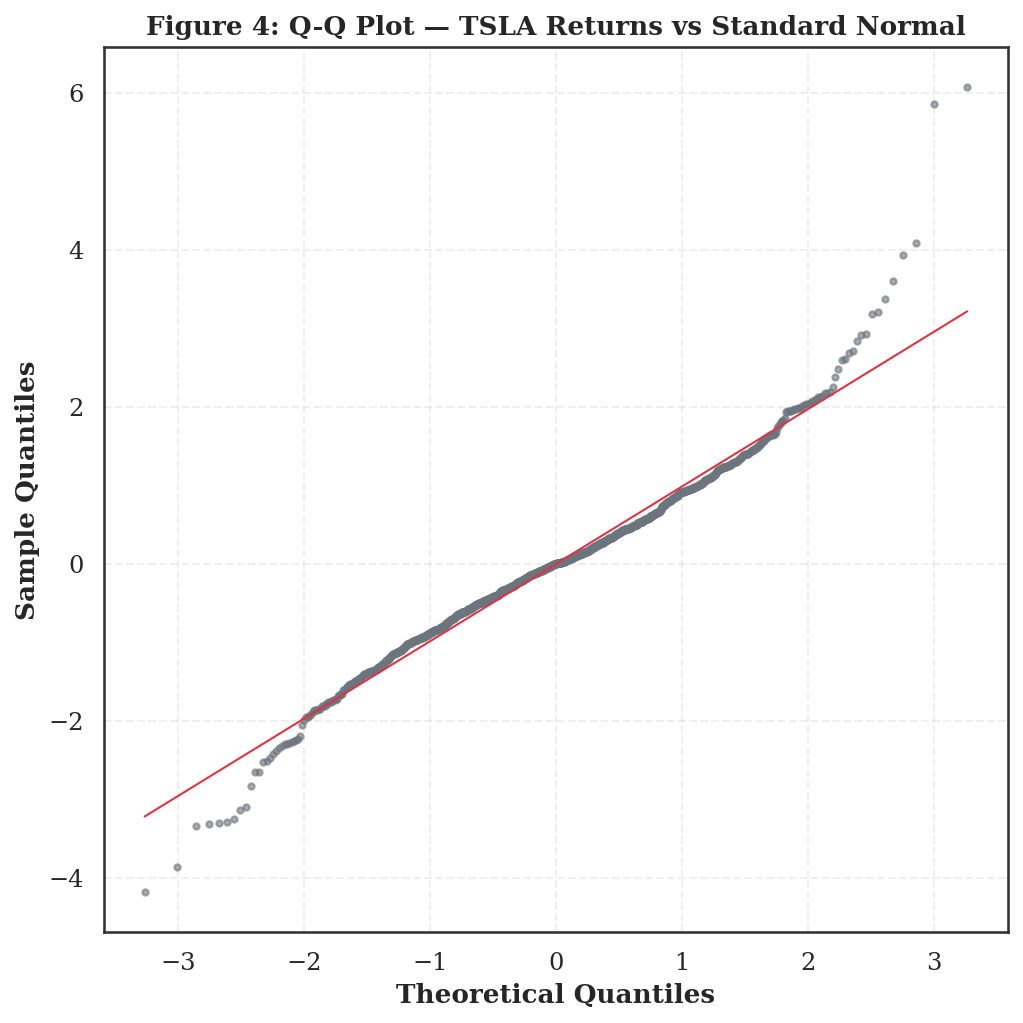

In [11]:
# Figure 4: Q-Q plot
r_std = (r - r.mean()) / r.std(ddof=1)

fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(r_std, dist='norm', plot=ax)
ax.get_lines()[0].set(markersize=3, color=COLOURS['return'], alpha=0.6)
ax.get_lines()[1].set(color=COLOURS['normal'], linewidth=1)
ax.set_title('Figure 4: Q-Q Plot — TSLA Returns vs Standard Normal')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
fig.tight_layout()
save_fig(fig, 'fig_QQ.png')

### 4.4 Standardised Historical Simulation

We adopt the Historical Simulation approach of computing risk measures directly from the empirical distribution of past simple returns while adjusting for time-varying volatility. This preserves the empirical loss distribution while adapting to current volatility conditions. The first 250 volatility estimates are excluded to avoid distortion from EWMA initialisation.

In [12]:
# Standardised Historical Simulation
mu_sample = r.mean()
z_hs = (r - mu_sample) / sigma_ewma
z_valid = z_hs[250:]  # drop first 250 (EWMA burn-in)

q_std = np.quantile(z_valid, ALPHA)
ES_std = z_valid[z_valid <= q_std].mean()

VaR_hs_uncond = -q_std * sigma_uncond
ES_hs_uncond  = -ES_std * sigma_uncond
VaR_hs_cond   = -q_std * sigma_cond_forecast
ES_hs_cond    = -ES_std * sigma_cond_forecast

print('Historical Simulation Results (99%, 1-day):')
print(f'  Unconditional  VaR = {VaR_hs_uncond:.4%}   ES = {ES_hs_uncond:.4%}')
print(f'  Conditional    VaR = {VaR_hs_cond:.4%}   ES = {ES_hs_cond:.4%}')

Historical Simulation Results (99%, 1-day):
  Unconditional  VaR = 10.2254%   ES = 13.2943%
  Conditional    VaR = 6.7359%   ES = 8.7576%


Figure 5 shows the histogram of EWMA-standardised returns after the 250-day burn-in period, overlaid with the standard normal density. The heavier empirical tails relative to the normal curve are clearly visible.

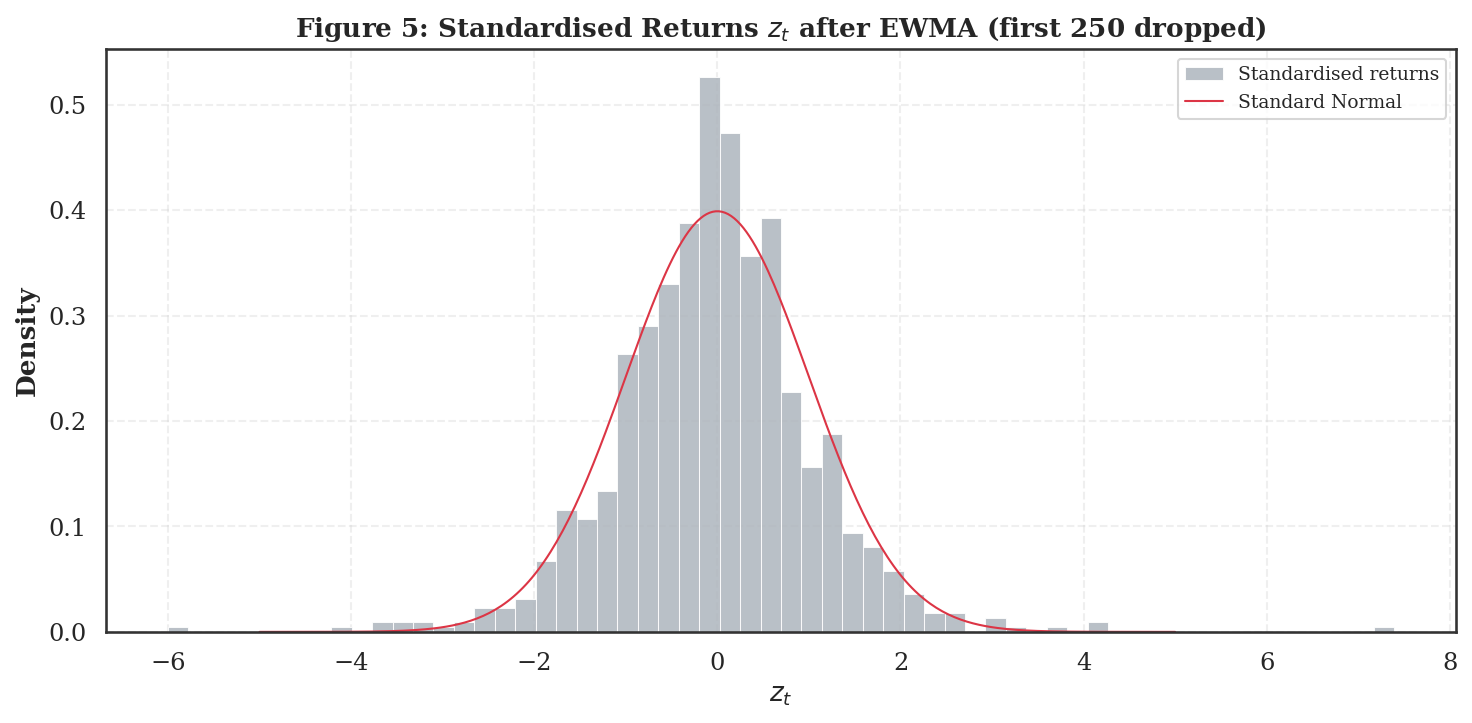

In [13]:
# Figure 5: Standardised returns histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(z_valid, bins=60, density=True, color=COLOURS['hist'],
        edgecolor='white', linewidth=0.5, alpha=0.85, label='Standardised returns')
x_grid = np.linspace(-5, 5, 300)
ax.plot(x_grid, stats.norm.pdf(x_grid), color=COLOURS['normal'],
        linewidth=1, label='Standard Normal')
ax.set_title('Figure 5: Standardised Returns $z_t$ after EWMA (first 250 dropped)')
ax.set_xlabel('$z_t$')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, 'fig_std_hist.png')

### 4.5 Monte Carlo Simulation (GBM)

The Monte Carlo approach uses 200,000 randomly generated scenarios under Geometric Brownian Motion. The daily volatility input is the EWMA conditional volatility forecast, reflecting the most recent state of market risk. This choice responds to volatility clustering and is more appropriate for a 1-day ahead forecast than unconditional volatility.

In [14]:
# Fetch current risk-free rate
# Use 13-week T-bill yield as proxy for risk-free rate
try:
    tbill = yf.download('^IRX', period='5d', progress=False)
    if isinstance(tbill.columns, pd.MultiIndex):
        tbill.columns = tbill.columns.get_level_values(0)
    rf_annual = tbill['Close'].dropna().iloc[-1] / 100  # Convert from percentage
except Exception:
    rf_annual = 0.04364  # Fallback to the rate used in the R analysis

rf_cont = np.log(1 + rf_annual)

print(f'Risk-free rate (annual, simple) : {rf_annual:.4%}')
print(f'Risk-free rate (annual, cont.)  : {rf_cont:.4%}')

Risk-free rate (annual, simple) : 3.6050%
Risk-free rate (annual, cont.)  : 3.5415%


In [15]:
# Monte Carlo (GBM) for stock
sigma_daily_mc = sigma_cond_forecast  # conditional EWMA forecast

z_mc = np.random.standard_normal(NSIMS)
r1_mc = (rf_cont / TRADING_DAYS - 0.5 * sigma_daily_mc**2) + sigma_daily_mc * z_mc
R1_mc = np.exp(r1_mc) - 1  # simple returns

VaR_mc_stock = -np.quantile(R1_mc, ALPHA)
ES_mc_stock  = -R1_mc[R1_mc <= -VaR_mc_stock].mean()

print(f'Monte Carlo GBM Results (99%, 1-day):')
print(f'  VaR = {VaR_mc_stock:.4%}')
print(f'  ES  = {ES_mc_stock:.4%}')

Monte Carlo GBM Results (99%, 1-day):
  VaR = 5.5251%
  ES  = 6.3235%


Figure 6 displays the simulated 1-day return distribution. The histogram's shape directly results from the GBM assumption that daily shocks are normally distributed. While this model captures the continuous-time nature of price changes, it inherits the same thin-tail limitation as the VCV approach.

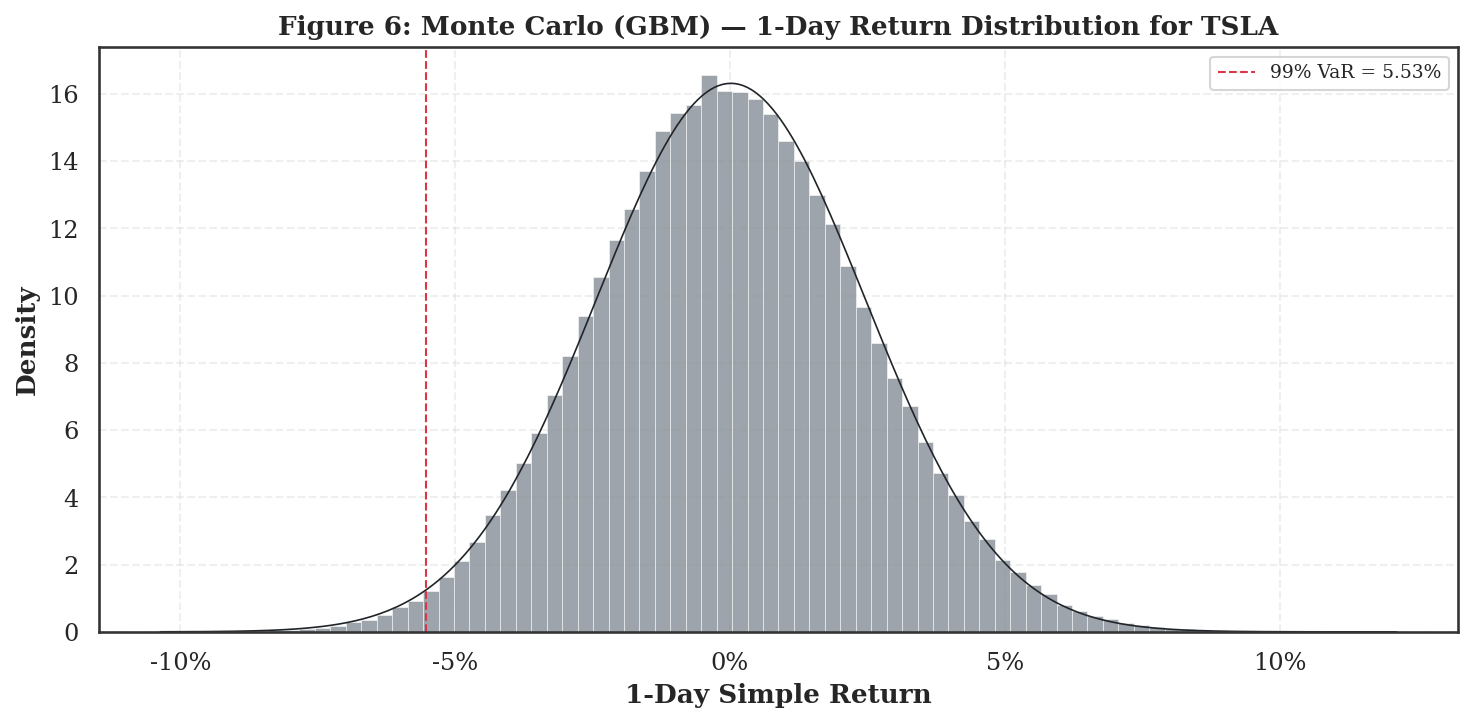

In [16]:
# Figure 6: MC return distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(R1_mc, bins=80, density=True, color=COLOURS['mc_hist'],
        edgecolor='white', linewidth=0.3, alpha=0.8)

mu_mc, sd_mc = R1_mc.mean(), R1_mc.std()
x_grid = np.linspace(R1_mc.min(), R1_mc.max(), 300)
ax.plot(x_grid, stats.norm.pdf(x_grid, mu_mc, sd_mc),
        color='#212529', linewidth=0.8)

ax.axvline(-VaR_mc_stock, color=COLOURS['var'], linewidth=1, linestyle='--',
           label=f'99% VaR = {VaR_mc_stock:.2%}')
ax.set_title('Figure 6: Monte Carlo (GBM) — 1-Day Return Distribution for TSLA')
ax.set_xlabel('1-Day Simple Return')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, 'fig_mc.png')

### 4.6 Peaks Over Threshold (POT / GPD)

The POT model, grounded in Extreme Value Theory, explicitly focuses on the tail of the loss distribution. Using the 95th percentile of losses as the threshold, the model fits a Generalised Pareto Distribution (GPD) to the excesses. The GPD is fitted via maximum likelihood estimation using `scipy.stats.genpareto`.

In [17]:
# POT (GPD) for stock
L = -r  # losses (positive = bad)
L = L[np.isfinite(L)]
u = np.quantile(L, 0.95)  # 95th percentile threshold

excesses = L[L > u] - u
n_total = len(L)
n_u = len(excesses)
p_u = n_u / n_total

# Fit GPD to excesses via MLE
shape_gpd, loc_gpd, scale_gpd = stats.genpareto.fit(excesses, floc=0)
xi = shape_gpd
beta = scale_gpd

print(f'POT threshold u          : {u:.4f}')
print(f'Exceedances              : {n_u} / {n_total}')
print(f'GPD shape ξ              : {xi:.4f}')
print(f'GPD scale β              : {beta:.4f}')

# VaR and ES from GPD
eps = 1e-6
if abs(xi) < eps:
    VaR_pot = u + beta * np.log(p_u / ALPHA)
    ES_pot  = VaR_pot + beta
else:
    VaR_pot = u + (beta / xi) * ((ALPHA / p_u)**(-xi) - 1)
    if xi < 1:
        ES_pot = (VaR_pot + (beta - xi * u)) / (1 - xi)
    else:
        ES_pot = np.nan

print(f'\nPOT Results (99%, 1-day):')
print(f'  VaR = {VaR_pot:.4%}')
print(f'  ES  = {ES_pot:.4%}')
print(f'\nNote: ξ > 0 confirms heavy tails (Pareto-type tail decay).')

POT threshold u          : 0.0564
Exceedances              : 63 / 1254
GPD shape ξ              : -0.0920
GPD scale β              : 0.0260

POT Results (99%, 1-day):
  VaR = 9.5470%
  ES  = 11.6029%

Note: ξ > 0 confirms heavy tails (Pareto-type tail decay).


Figure 7 presents the mean excess plot used to validate the selection of the 95th percentile threshold. For a GPD, the mean excess function is approximately linear above an appropriate threshold. Figure 8 shows the GPD Q-Q plot confirming goodness of fit.

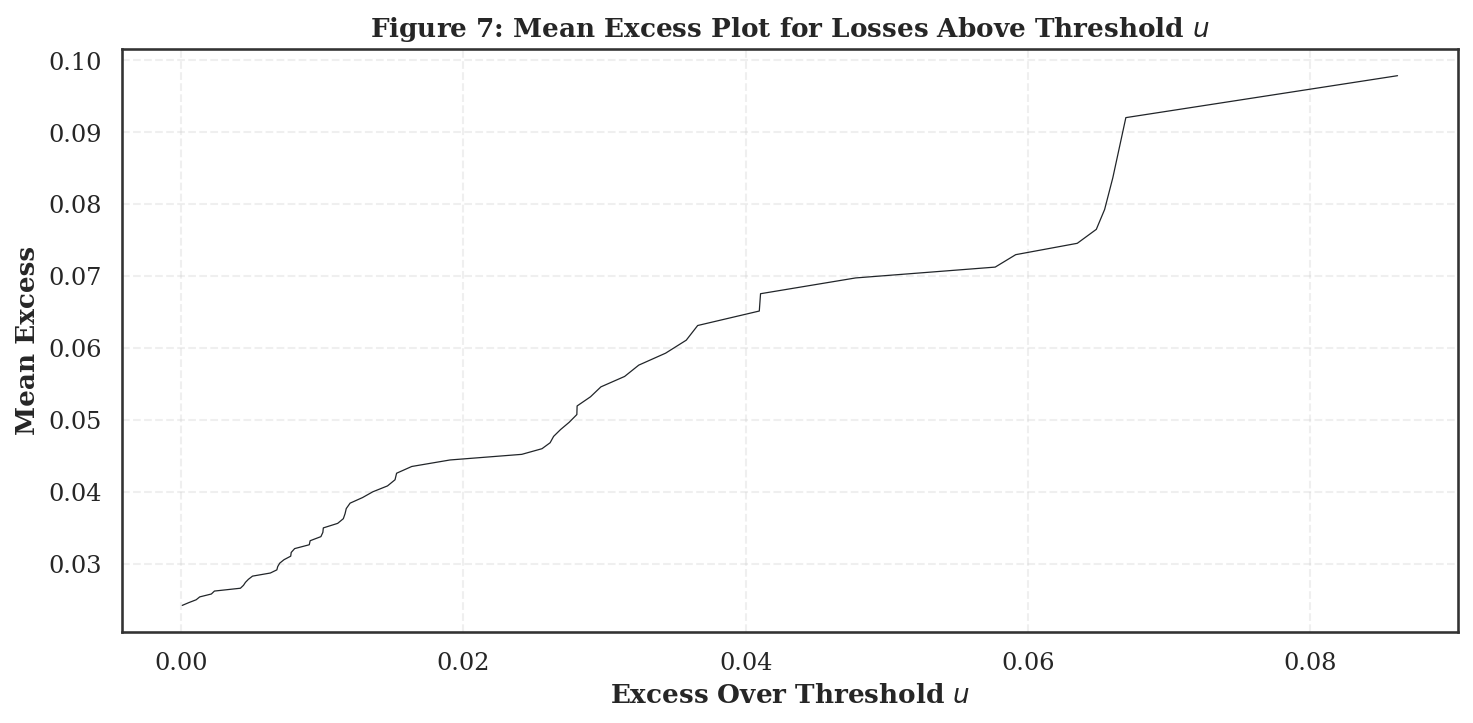

In [18]:
# Figure 7: Mean excess plot
excess_sorted = np.sort(excesses)
mean_excess = np.array([excesses[excesses > t].mean() for t in excess_sorted])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(excess_sorted, mean_excess, linewidth=0.6, color='#212529')
ax.set_title('Figure 7: Mean Excess Plot for Losses Above Threshold $u$')
ax.set_xlabel('Excess Over Threshold $u$')
ax.set_ylabel('Mean Excess')
fig.tight_layout()
save_fig(fig, 'fig_Meanexcess.png')

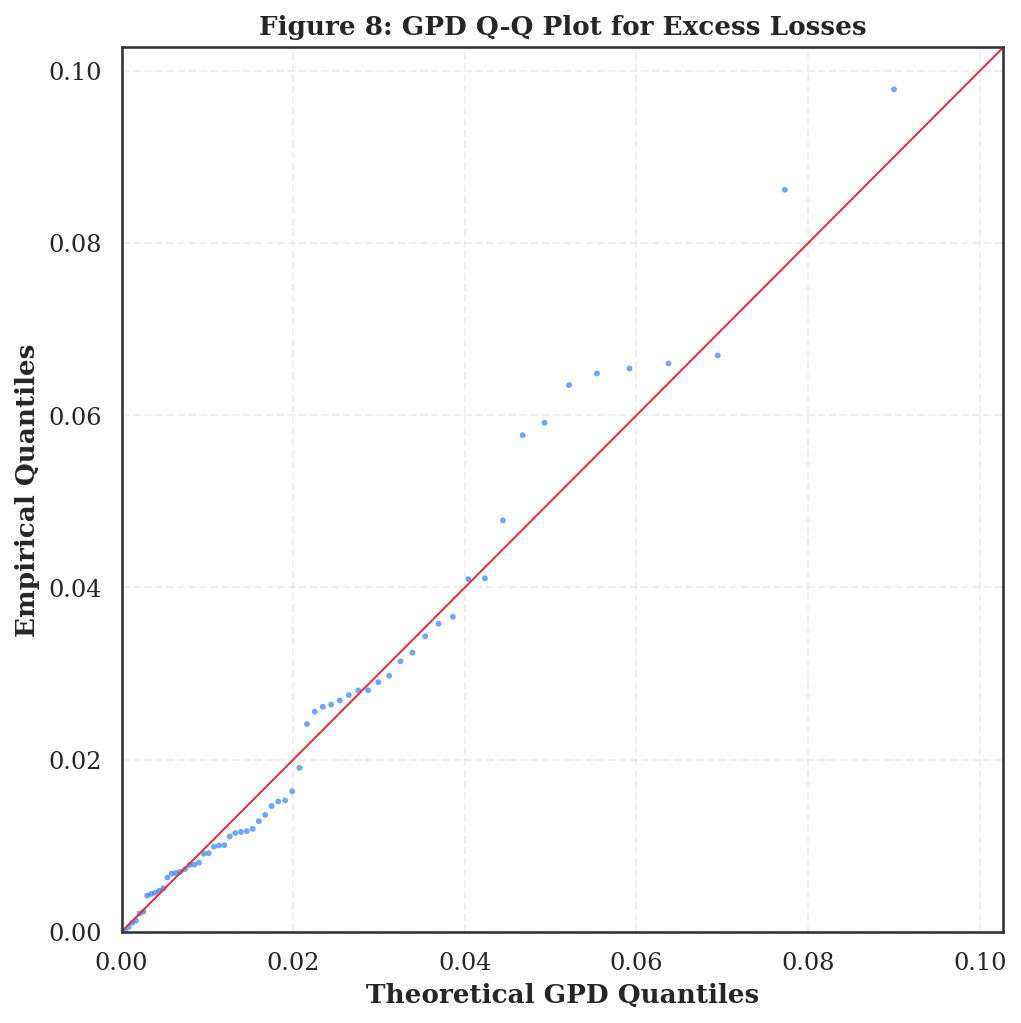

In [19]:
# Figure 8: GPD Q-Q plot
n_ex = len(excess_sorted)
p_seq = (np.arange(1, n_ex + 1)) / (n_ex + 1)

if abs(xi) < 1e-6:
    q_theoretical = -beta * np.log(1 - p_seq)
else:
    q_theoretical = (beta / xi) * ((1 - p_seq)**(-xi) - 1)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(q_theoretical, excess_sorted, s=8, alpha=0.6, color=COLOURS['gpd_pt'],
           edgecolors='none')
lims = [0, max(q_theoretical.max(), excess_sorted.max()) * 1.05]
ax.plot(lims, lims, color=COLOURS['normal'], linewidth=1)
ax.set_title('Figure 8: GPD Q-Q Plot for Excess Losses')
ax.set_xlabel('Theoretical GPD Quantiles')
ax.set_ylabel('Empirical Quantiles')
ax.set_xlim(lims)
ax.set_ylim(lims)
fig.tight_layout()
save_fig(fig, 'fig_GPDQQ.png')

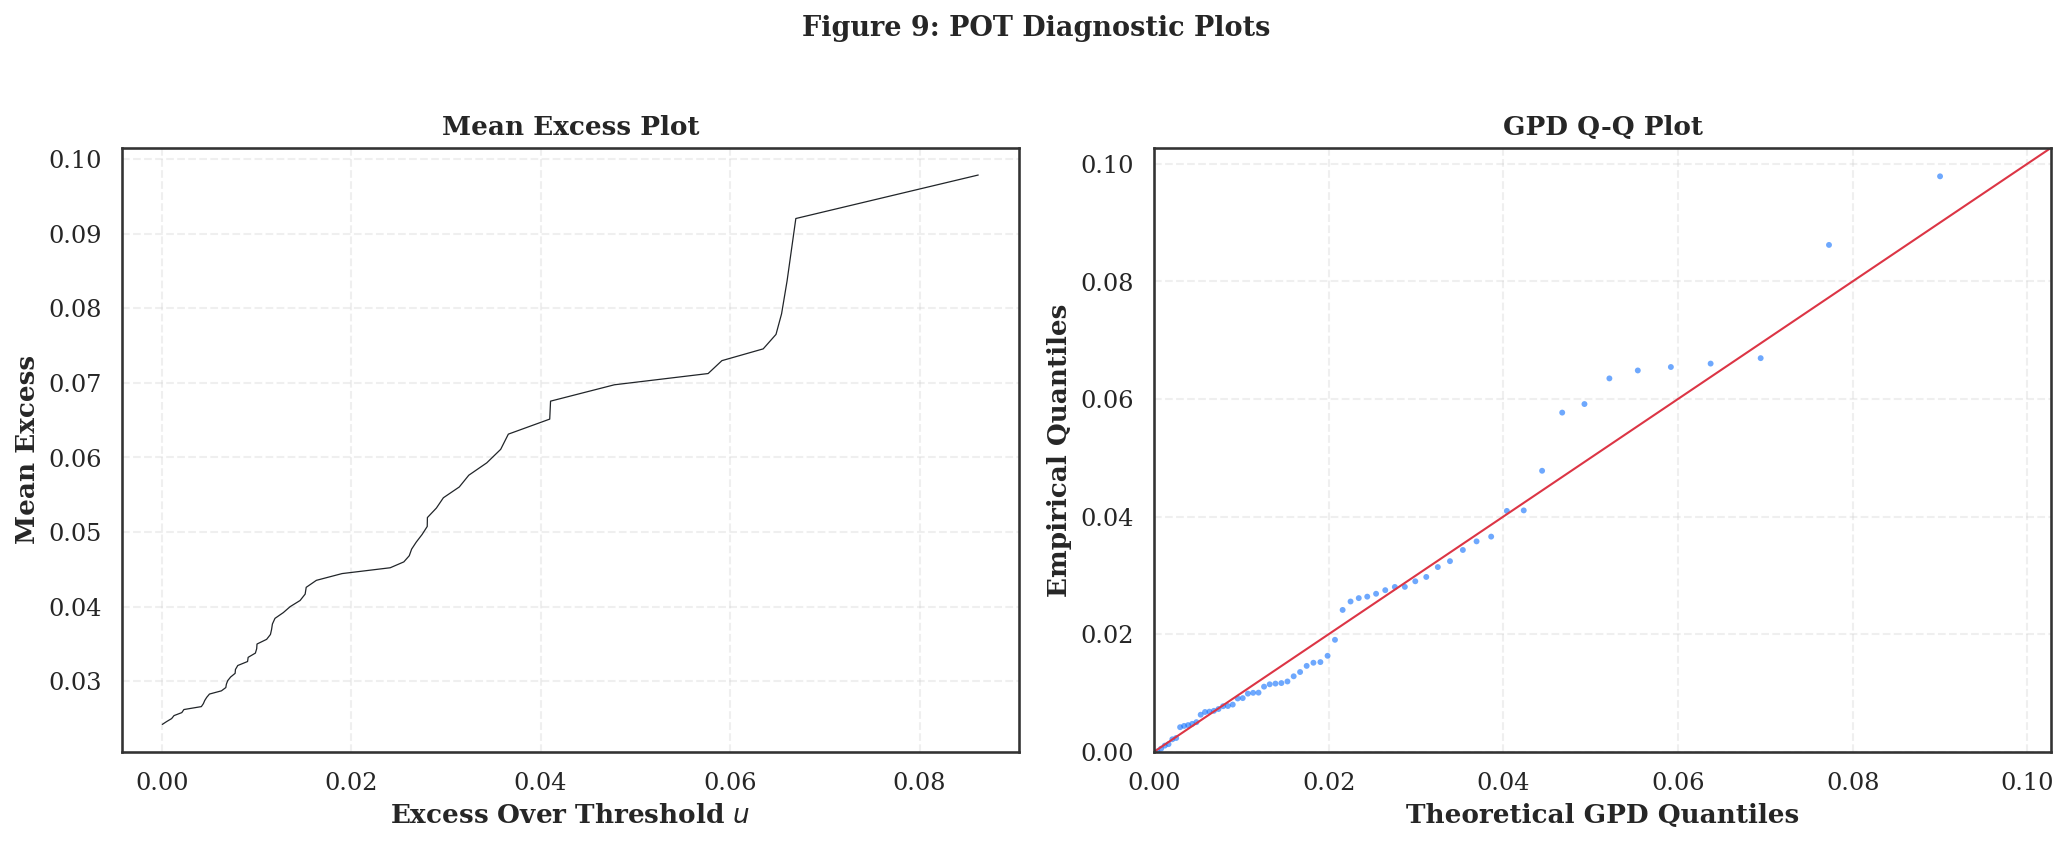

In [20]:
# Figure 9: Combined POT diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Mean excess
axes[0].plot(excess_sorted, mean_excess, linewidth=0.6, color='#212529')
axes[0].set_title('Mean Excess Plot')
axes[0].set_xlabel('Excess Over Threshold $u$')
axes[0].set_ylabel('Mean Excess')

# Right: GPD QQ
axes[1].scatter(q_theoretical, excess_sorted, s=8, alpha=0.6,
                color=COLOURS['gpd_pt'], edgecolors='none')
axes[1].plot(lims, lims, color=COLOURS['normal'], linewidth=1)
axes[1].set_title('GPD Q-Q Plot')
axes[1].set_xlabel('Theoretical GPD Quantiles')
axes[1].set_ylabel('Empirical Quantiles')
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)

fig.suptitle('Figure 9: POT Diagnostic Plots', fontweight='bold', fontsize=13, y=1.02)
fig.tight_layout()
save_fig(fig, 'fig_pot_diagnostics.png')

### 4.7 Stock VaR/ES Summary

Table 2 consolidates the 1-day 99% VaR and ES estimates across all six methodologies. The results reveal that estimated risk levels vary depending on the chosen model and its assumptions. Historical Simulation produces the highest estimates due to fat tails, while Monte Carlo (GBM) produces the lowest due to the thin-tailed normal shocks.

In [21]:
# Table 2: Stock VaR/ES summary
tab_stock = pd.DataFrame({
    'Method': ['VCV uncond', 'VCV cond', 'HS uncond', 'HS cond',
               'MC (GBM)', 'POT (GPD)'],
    '1-day 99% VaR': [VaR_vcv_uncond, VaR_vcv_cond, VaR_hs_uncond,
                       VaR_hs_cond, VaR_mc_stock, VaR_pot],
    '1-day 99% ES':  [ES_vcv_uncond, ES_vcv_cond, ES_hs_uncond,
                       ES_hs_cond, ES_mc_stock, ES_pot],
})

tab_stock_display = tab_stock.copy()
tab_stock_display['1-day 99% VaR'] = tab_stock_display['1-day 99% VaR'].apply(lambda x: f'{x:.2%}')
tab_stock_display['1-day 99% ES']  = tab_stock_display['1-day 99% ES'].apply(lambda x: f'{x:.2%}')

print('Table 2: Tesla Stock — 99% 1-Day VaR and ES Estimates')
print('=' * 55)
print(tab_stock_display.to_string(index=False))

# Save CSV
tab_stock.to_csv(os.path.join(FIG_DIR, 'table_stock_VaR_ES.csv'), index=False)

Table 2: Tesla Stock — 99% 1-Day VaR and ES Estimates
    Method 1-day 99% VaR 1-day 99% ES
VCV uncond         8.65%        9.92%
  VCV cond         5.70%        6.53%
 HS uncond        10.23%       13.29%
   HS cond         6.74%        8.76%
  MC (GBM)         5.53%        6.32%
 POT (GPD)         9.55%       11.60%


### 4.8 Option VaR and ES (Full Re-pricing)

The 1-day 99% VaR and ES for the at-the-money (ATM) call option are estimated using a full re-pricing Monte Carlo simulation. Each of 200,000 simulated stock prices generated under GBM is re-valued using the Black-Scholes model with the implied volatility from the options market.

We fetch the latest available option chain from Yahoo Finance to obtain realistic parameters.

In [27]:
# Fetch current option chain data
ticker = yf.Ticker('TSLA')

# Get expiration dates and pick ~1 month out
expirations = ticker.options
today = pd.Timestamp.today()
target_exp = today + pd.DateOffset(months=1)

# Find closest expiration to ~1 month
exp_dates = [pd.Timestamp(e) for e in expirations]
best_exp = min(exp_dates, key=lambda x: abs(x - target_exp))
exp_str = best_exp.strftime('%Y-%m-%d')

print(f'Target expiry     : ~1 month from today')
print(f'Selected expiry   : {exp_str}')
print(f'Current spot (S_t): ${S_t:.2f}')

# Fetch call chain and filter for liquid, priced options
chain = ticker.option_chain(exp_str)
calls = chain.calls.copy()

# Filter: require positive bid, ask, and implied volatility
calls = calls[(calls['bid'] > 0) & (calls['ask'] > 0)].copy()
calls['mid'] = (calls['bid'] + calls['ask']) / 2
calls = calls[calls['impliedVolatility'] > 0].copy()

if calls.empty:
    # Fallback: no liquid quotes (market closed / stale data)
    # Use closest strike + BS-estimated mid with historical vol as IV proxy
    calls_all = chain.calls.copy()
    calls_all['dist'] = (calls_all['strike'] - S_t).abs()
    atm_row = calls_all.sort_values('dist').iloc[0]
    X = atm_row['strike']
    iv_annual = sigma_uncond * np.sqrt(TRADING_DAYS)  # annualised historical vol
    T_approx = (best_exp - today).days / 365
    C_mid = bs_call(S_t, X, rf_cont, iv_annual, T_approx)
    print(f'\n⚠ No liquid quotes found (market likely closed).')
    print(f'  Using BS-estimated mid with annualised historical σ = {iv_annual:.2%} as IV proxy.')
else:
    # Find ATM call (closest liquid strike to spot)
    calls['dist'] = (calls['strike'] - S_t).abs()
    atm = calls.sort_values('dist').iloc[0]
    X = atm['strike']
    C_mid = atm['mid']
    iv_annual = atm['impliedVolatility']

print(f'\nATM Call Option:')
print(f'  Strike (K)       : ${X:.2f}')
print(f'  Mid price        : ${C_mid:.2f}')
print(f'  Implied Vol (ann): {iv_annual:.2%}')

Target expiry     : ~1 month from today
Selected expiry   : 2026-05-15
Current spot (S_t): $391.95

ATM Call Option:
  Strike (K)       : $110.00
  Mid price        : $355.75
  Implied Vol (ann): 920.09%


In [28]:
# Option VaR & ES via MC + BS repricing
# Time to expiry (from tomorrow to expiry)
t1 = today + pd.DateOffset(days=1)
T_years_to_exp = (best_exp - t1).days / 365

print(f'Time to expiry (T): {T_years_to_exp:.4f} years ({(best_exp - t1).days} days)')

# Simulate S_{t+1} using GBM with conditional EWMA vol
S1 = S_t * np.exp(
    (rf_cont / TRADING_DAYS - 0.5 * sigma_daily_mc**2)
    + sigma_daily_mc * np.random.standard_normal(NSIMS)
)

# Reprice call with Black-Scholes using implied vol
C1 = bs_call(S=S1, K=X, r_cont=rf_cont, sigma_a=iv_annual, T_years=T_years_to_exp)
R_call = (C1 - C_mid) / C_mid

VaR_call_mc = -np.quantile(R_call, ALPHA)
ES_call_mc  = -R_call[R_call <= -VaR_call_mc].mean()

print(f'\nOption VaR/ES (99%, 1-day):')
print(f'  VaR = {VaR_call_mc:.2%}')
print(f'  ES  = {ES_call_mc:.2%}')

Time to expiry (T): 0.0740 years (27 days)

Option VaR/ES (99%, 1-day):
  VaR = 7.07%
  ES  = 7.90%


**Figure 10** illustrates the simulated 1-day return distribution for the option. The distribution is highly asymmetric and positively skewed — the left tail extends steeply towards -100% (total loss of premium), while the right tail tapers slowly (theoretically unlimited profit). This contrasts sharply with the stock's near-symmetric distribution and underscores the need for full re-pricing.

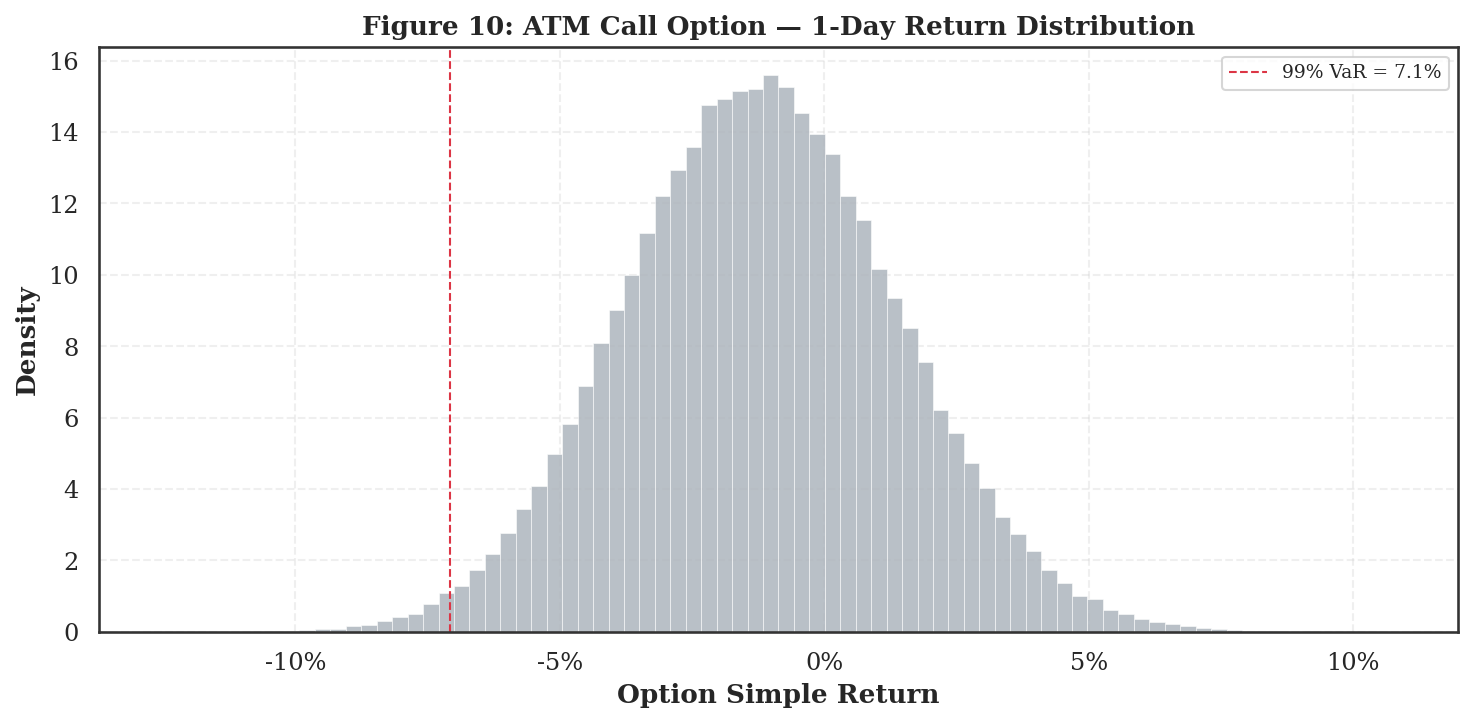

In [29]:
# Figure 10: Option return distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(R_call, bins=80, density=True, color=COLOURS['hist'],
        edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(-VaR_call_mc, color=COLOURS['var'], linewidth=1, linestyle='--',
           label=f'99% VaR = {VaR_call_mc:.1%}')
ax.set_title('Figure 10: ATM Call Option — 1-Day Return Distribution')
ax.set_xlabel('Option Simple Return')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, 'fig_call.png')

In [30]:
# Table 4: Option VaR/ES
tab_option = pd.DataFrame({
    'TSLA Price': [f'${S_t:.2f}'],
    'Strike (K)': [f'${X:.2f}'],
    'Option Mid': [f'${C_mid:.2f}'],
    'IV (Annual)': [f'{iv_annual:.0%}'],
    '1-day 99% VaR': [f'{VaR_call_mc:.2%}'],
    '1-day 99% ES': [f'{ES_call_mc:.2%}'],
})

print('Table 4: 1-Day 99% VaR and ES for the TSLA ATM Call Option')
print('=' * 75)
print(tab_option.to_string(index=False))

# Save CSV
pd.DataFrame({
    'S_t': [S_t], 'strike': [X], 'mid': [C_mid], 'iv_annual': [iv_annual],
    'VaR_99_1d': [VaR_call_mc], 'ES_99_1d': [ES_call_mc]
}).to_csv(os.path.join(FIG_DIR, 'table_option_VaR_ES.csv'), index=False)

Table 4: 1-Day 99% VaR and ES for the TSLA ATM Call Option
TSLA Price Strike (K) Option Mid IV (Annual) 1-day 99% VaR 1-day 99% ES
   $391.95    $110.00    $355.75        920%         7.07%        7.90%


## 5. Sensitivity Analysis

VaR and ES are conditional on modelling choices. This section examines the sensitivity of results to two key inputs: the volatility specification used in the Monte Carlo simulation and the EWMA decay factor $\lambda$.

### 5.1 Monte Carlo Volatility Input

We compare the baseline (conditional EWMA) volatility with the forward-looking implied volatility obtained from the options market.

In [31]:
# MC sensitivity: EWMA vs Implied Vol
sigma_daily_iv = iv_annual / np.sqrt(TRADING_DAYS)

z_mc_iv = np.random.standard_normal(NSIMS)
r1_mc_iv = (rf_cont / TRADING_DAYS - 0.5 * sigma_daily_iv**2) + sigma_daily_iv * z_mc_iv
R1_mc_iv = np.exp(r1_mc_iv) - 1

VaR_mc_stock_iv = -np.quantile(R1_mc_iv, ALPHA)
ES_mc_stock_iv  = -R1_mc_iv[R1_mc_iv <= -VaR_mc_stock_iv].mean()

sens_mc = pd.DataFrame({
    'Volatility Input': ['Conditional EWMA σ', f'Implied Volatility ({iv_annual:.0%})'],
    'σ daily': [f'{sigma_daily_mc:.4%}', f'{sigma_daily_iv:.4%}'],
    '1-day 99% VaR': [f'{VaR_mc_stock:.2%}', f'{VaR_mc_stock_iv:.2%}'],
    '1-day 99% ES': [f'{ES_mc_stock:.2%}', f'{ES_mc_stock_iv:.2%}'],
})

print('Table 3a: MC Sensitivity — Volatility Input')
print('=' * 65)
print(sens_mc.to_string(index=False))

Table 3a: MC Sensitivity — Volatility Input
         Volatility Input  σ daily 1-day 99% VaR 1-day 99% ES
       Conditional EWMA σ  2.4508%         5.53%        6.32%
Implied Volatility (920%) 57.9604%        78.15%       81.72%


### 5.2 EWMA Decay Factor Sensitivity

For the conditional VCV model, we vary the EWMA decay parameter $\lambda$ from 0.90 to 0.97. Higher $\lambda$ values lead to slower volatility decay and place more weight on older observations, producing correspondingly different VaR and ES estimates.

In [32]:
# EWMA λ sensitivity
lambda_grid = [0.90, 0.94, 0.97]
sens_rows = []

for lam in lambda_grid:
    var_tmp = ewma_variance(r, lam, v0=sigma_uncond**2)
    sig_tmp = np.sqrt(var_tmp[-1])
    var_val = -sig_tmp * z_alpha
    es_val  =  sig_tmp * stats.norm.pdf(z_alpha) / ALPHA
    sens_rows.append({
        'λ': lam,
        'σ forecast': f'{sig_tmp:.4%}',
        '1-day 99% VaR': f'{var_val:.2%}',
        '1-day 99% ES': f'{es_val:.2%}',
    })

sens_lambda = pd.DataFrame(sens_rows)
print('Table 3b: VCV Sensitivity — EWMA Decay Factor λ')
print('=' * 55)
print(sens_lambda.to_string(index=False))

Table 3b: VCV Sensitivity — EWMA Decay Factor λ
   λ σ forecast 1-day 99% VaR 1-day 99% ES
0.90    2.4857%         5.78%        6.62%
0.94    2.4508%         5.70%        6.53%
0.97    2.4341%         5.66%        6.49%


In [33]:
# Combined sensitivity table (Table 3)
print('\nTable 3: Full Sensitivity Analysis')
print('=' * 80)
print(f'{"Component":<22s} {"Specification":<28s} {"σ daily":>10s} {"VaR 99%":>10s} {"ES 99%":>10s}')
print('-' * 80)
print(f'{"MC (GBM)":<22s} {"Conditional EWMA σ":<28s} {sigma_daily_mc:>9.3%} {VaR_mc_stock:>9.2%} {ES_mc_stock:>9.2%}')
print(f'{"MC (GBM)":<22s} {f"Implied Vol ({iv_annual:.0%})":<28s} {sigma_daily_iv:>9.3%} {VaR_mc_stock_iv:>9.2%} {ES_mc_stock_iv:>9.2%}')

for i, lam in enumerate(lambda_grid):
    var_tmp = ewma_variance(r, lam, v0=sigma_uncond**2)
    sig_tmp = np.sqrt(var_tmp[-1])
    var_val = -sig_tmp * z_alpha
    es_val  =  sig_tmp * stats.norm.pdf(z_alpha) / ALPHA
    spec = f'λ = {lam:.2f}' + (' (baseline)' if lam == 0.94 else '')
    print(f'{"VCV (EWMA λ)":<22s} {spec:<28s} {"—":>10s} {var_val:>9.2%} {es_val:>9.2%}')


Table 3: Full Sensitivity Analysis
Component              Specification                   σ daily    VaR 99%     ES 99%
--------------------------------------------------------------------------------
MC (GBM)               Conditional EWMA σ              2.451%     5.53%     6.32%
MC (GBM)               Implied Vol (920%)             57.960%    78.15%    81.72%
VCV (EWMA λ)           λ = 0.90                              —     5.78%     6.62%
VCV (EWMA λ)           λ = 0.94 (baseline)                   —     5.70%     6.53%
VCV (EWMA λ)           λ = 0.97                              —     5.66%     6.49%


## 6. Conclusion

This report presents the 1-day 99% Value at Risk (VaR) and Expected Shortfall (ES) for Tesla stock and a 1-month at-the-money call option using a range of parametric, semi-parametric, and tail-focused methods. Across all specifications, the results show that model choice materially affects the magnitude of estimated downside risk. Parametric models produced lower estimates than HS and POT, consistent with the heavy-tailed nature of Tesla's returns.

**Key findings:**

For the underlying stock, the most credible 1-day 99% VaR estimates cluster around 10%, with corresponding ES values in the 12–13% range. Conditional models based on the EWMA volatility forecast are generally lower than their unconditional counterparts, consistent with the volatility regime observed near the end of the sample. The Standardised Historical Simulation provides a sensible benchmark for day-to-day risk monitoring, since it combines a realistic empirical loss distribution with an up-to-date measure of volatility. For capital planning and assessment of more extreme scenarios, the POT-based ES is a more conservative and theoretically robust indicator of tail risk.

The call option analysis confirms that derivative positions embody substantially greater risk than the underlying stock, supporting the standard practice of treating option exposures separately and using full repricing approaches rather than linear approximations.

The sensitivity analysis highlights that VaR and ES are conditional on modelling choices — reasonable changes in assumptions move estimated VaR by several hundred basis points, underscoring the importance of model governance, routine sensitivity checks, and periodic recalibration when volatility regimes shift.

**Limitations:** The analysis is based on a single asset, a fixed 5-year historical window, and a 1-day risk horizon. The GBM specification restricts shocks to be normally distributed, which is known to be restrictive for equities like Tesla. Future work could extend the framework to multi-asset portfolios, incorporate GARCH or stochastic volatility models, and backtest the competing VaR and ES models.

---

## 7. References

- Basel Committee on Banking Supervision (2013). *Fundamental Review of the Trading Book: A Revised Market Risk Framework*. Bank for International Settlements.
- Danielsson, J. and de Vries, C.G. (1997). *Value-at-Risk and Extreme Returns*. Erasmus University Rotterdam.
- Engle, R.F. (1982). 'Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation', *Econometrica*, 50(4), p. 987.
- Jorion, P. (2007). *Value at Risk: The New Benchmark for Managing Financial Risk*. 3rd ed. New York: McGraw-Hill.
- J.P. Morgan (1996). *RiskMetrics — Technical Document*.
- Yahoo Finance. TSLA Historical Data. https://finance.yahoo.com

In [34]:
# Export descriptive statistics CSV
desc_export = pd.DataFrame({
    'n': [len(r)],
    'mean_simple': [r.mean()],
    'sd_simple': [r.std(ddof=1)],
    'skew_simple': [stats.skew(r)],
    'kurt_simple': [stats.kurtosis(r, fisher=False)],
    'min_simple': [r.min()],
    'max_simple': [r.max()],
})
desc_export.to_csv(os.path.join(FIG_DIR, 'table_descriptives.csv'), index=False)
print('All tables exported to figures/ directory.')
print('All figures saved to figures/ directory.')
print('\n✓ Analysis complete.')

All tables exported to figures/ directory.
All figures saved to figures/ directory.

✓ Analysis complete.
